In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

## Part 1 — Problem Definition & Dataset Verification

**Tasks**

1.Load clean_churn.csv (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no
missing values remaining.




In [6]:
df = pd.read_csv("clean_churn.csv")

In [8]:
df.shape

(7043, 21)

In [9]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

# 2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?


# ANS : The ML problem is to predict whether a customer is likely to churn (leave the company) based on their characteristics and usage patterns. This matters because identifying high-risk customers early allows the company to take action and reduce customer loss and revenue.

## Part 2 - Feature & target Preparation

**Tasks**
3. Define y as the Churn column, encoded as 0/1. Define X as the remaining relevant columns — drop any identifier column still present.
    
4. Convert every remaining categorical column in X into numeric form. Briefly justify your choice of encoding
method (e.g. one-hot vs. manual mapping).
5. Confirm X contains only numeric columns and has no missing values before moving on.



In [68]:
y = df["Churn"].map({"No": 0, "Yes": 1})


In [69]:
X = df.drop(columns=["Churn", "customerID"])

In [70]:
X.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [79]:
## Now apply the One-hot encoding on X 
## I used one-hot encoding because the categorical variables do not have a
## meaningful numerical order. One-hot encoding converts each category into a binary numerical feature without incorrectly implying an ordinal relationship
X = pd.get_dummies(X, drop_first=True)

In [81]:
print(X.select_dtypes(include="object").columns)

Index([], dtype='object')


In [83]:
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

In [84]:
print(X.dtypes)
print("Non-numeric columns:", X.select_dtypes(exclude="number").columns.tolist())
print("Missing values:", X.isnull().sum().sum())

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
TechSupport_Yes                            int64
StreamingTV_No inter

## Part 3 — Train/Test Split 


**Tasks**

6. Split X and y into training and test sets (e.g. an 80/20 split). Why is stratify=y a sensible choice, given what you 
found about the targets class balance in Lab 2? 
7. Report the shape of X_train, X_test, y_train, and y_test. 

In [85]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                test_size=0.2,
                                                random_state=42,
                                                stratify=y)
## stratify=y is a sensible choice because the target variable is imbalanced. It preserves the proportion of churn and non-churn customers
## in both the training and test sets.

In [86]:
print("X_train: ",X_train.shape)
print("X_test: ",X_test.shape)
print("y_train: ",y_train.shape)
print("y_test: ",y_test.shape)

X_train:  (5634, 30)
X_test:  (1409, 30)
y_train:  (5634,)
y_test:  (1409,)


## Part 4 — Baseline Decision Tree 

**Tasks**
8. Train a DecisionTreeClassifier on the training data with default settings (only random_state fixed). Generate 
predictions on both the training and test sets. 

9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you? 

In [87]:
from sklearn.tree import DecisionTreeClassifier


In [88]:
dt = DecisionTreeClassifier(random_state=42)
#train
dt.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [89]:
## Prediction on training data
y_train_pred = dt.predict(X_train)
## prediction on test data
y_test_pred = dt.predict(X_test)

In [90]:
print("Tree depth :", dt.get_depth())

Tree depth : 23


In [56]:
## The Decision Tree grew to a depth of 23. This is not surprising because no max_depth was specified, so the tree was allowed to grow freely based on the training data. A depth of 23 suggests that
## the tree is quite complex and may be prone to overfitting

## Part 5 — Model Evaluation

**Tasks**

10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table. 
11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how 
many did it miss? 
12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

In [91]:
## 10
from sklearn.metrics import accuracy_score , precision_score, recall_score,f1_score


In [93]:
accuracy = accuracy_score(y_test,y_test_pred)
precision = precision_score(y_test,y_test_pred)
recall = recall_score(y_test,y_test_pred)
f1 = f1_score(y_test,y_test_pred)

result = pd.DataFrame({
    "Metrics" : ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score"  :  [accuracy, precision, recall, f1]
})


In [95]:
print(result)

     Metrics     Score
0   Accuracy  0.726047
1  Precision  0.483784
2     Recall  0.478610
3   F1-score  0.481183


In [96]:
## 11
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [98]:
cm =  confusion_matrix(y_test,y_test_pred)
print(cm)

[[844 191]
 [195 179]]


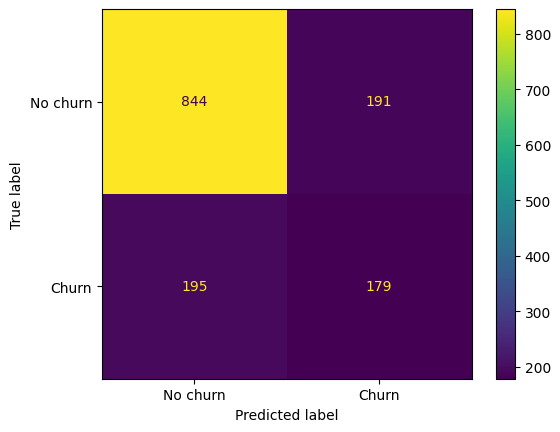

In [102]:
display =  ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No churn","Churn"])
display.plot()
plt.show()

In [104]:
## 12 
## I would focus most on Recall and F1-score.

## Recall is especially important because it tells us:

## Of all the customers who actually churned, how many did our model successfully identify?

## Part 6 — Overfitting Investigation

**Tasks**
13. Compare your baseline trees accuracy on the training set vs. the test set. Is there a large gap? What does that
suggest about the model?

14. Train several Decision Trees at different max_depth values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record
train accuracy and test accuracy for each in a results table.

16. Plot train accuracy and test accuracy against max_depth on the same chart. At roughly what depth does the
model start to overfit? Explain how the chart shows this.

In [113]:
## 13  Compare train vs test accuracy
train_acc = accuracy_score(y_train,dt.predict(X_train))
test_acc = accuracy_score(y_test, dt.predict(X_test))
print("Baseline decision tree")
print("Train accuracy : ",train_acc)
print("Test Accuracy :" , test_acc)
print("Gap :", {train_acc-test_acc})
print("Tree depth :",dt.get_depth())

Baseline decision tree
Train accuracy :  0.9980475683351083
Test Accuracy : 0.7260468417317246
Gap : {0.2720007266033837}
Tree depth : 23


In [115]:
## Yes, there's a large gap:
## This suggests the model is overfitting.

In [121]:
## 14 
depth = [2, 3, 4, 5, 6, 8, 10, None] 
result = []

for d in depth:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, tree.predict(X_train))
    test_acc = accuracy_score(y_test, tree.predict(X_test))
    
    result.append({
        "max_depth": d if d is not None else "Unrestricted",
        "train_accuracy": round(train_acc, 4),
        "test_accuracy": round(test_acc, 4),
        "gap": round(train_acc - test_acc, 4),
    })
    

In [125]:
result_df = pd.DataFrame(result)
print(result_df.to_string(index = False))
result_df.to_csv("depth_sweep_results.csv", index=False)


   max_depth  train_accuracy  test_accuracy     gap
           2          0.7911         0.7871  0.0040
           3          0.7911         0.7871  0.0040
           4          0.7925         0.7956 -0.0031
           5          0.8023         0.7942  0.0081
           6          0.8106         0.8006  0.0100
           8          0.8358         0.7828  0.0530
          10          0.8727         0.7551  0.1176
Unrestricted          0.9980         0.7260  0.2720


In [127]:
## 15 
df = pd.read_csv("depth_sweep_results.csv")

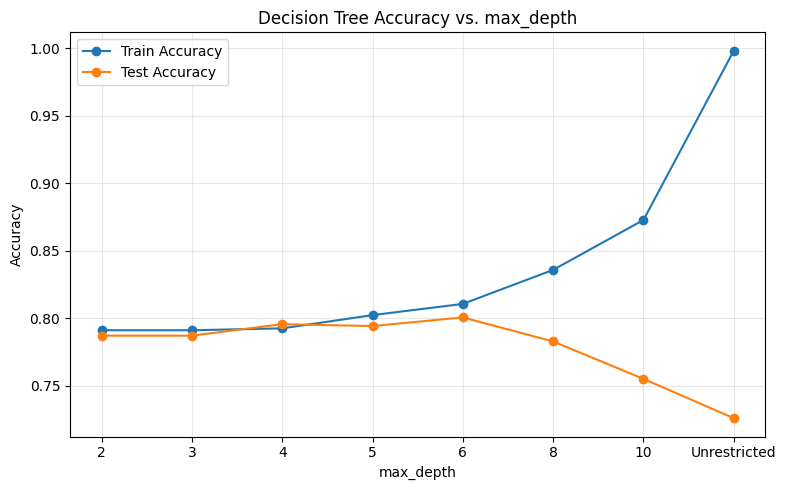

In [131]:
x_labels = df["max_depth"].astype(str)
x_pos = range(len(x_labels))
plt.figure(figsize=(8, 5))
plt.plot(x_pos, df["train_accuracy"], marker="o", label="Train Accuracy")
plt.plot(x_pos, df["test_accuracy"], marker="o", label="Test Accuracy")
plt.xticks(x_pos, x_labels)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs. max_depth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("depth_vs_accuracy.png", dpi=150)
plt.show()

In [132]:
## the model starts to overfit around depth 6
## That widening gap is the visual proof of overfitting. If the model were still learning general, useful patterns, both lines would keep rising together. Instead, only the train line keeps improving — meaning the model is just memorizing quirks of the training rows — while the test line gets worse, showing that memorization doesn't help (and actually hurts)
## performance on new, unseen data

## Part 7 — Model Selection, Feature Importance & Interpretation

**Task**

16. Based on your Part 6 table/plot, select a max_depth you consider the best model. Justify your choice in 2–3 
sentences — it should not simply be the depth with the highest training accuracy. 

17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Part 5) for comparison 
against the baseline.

19. Retrain a Decision Tree with “entropy” as the splitting criterion rather than the default (“gini”) and report its 
full evaluation metrics (as in Part 5) for comparison against the baseline.


21. Extract and visualize feature_importances_ for your chosen model. Which 3–5 features matter most? 

22. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the 
patterns you saw then? 

In [134]:
## 16

## I'm choosing depth 5 instead of the unrestricted tree (~99.9% train accuracy),
## since that model overfits and generalizes poorly. Depth 5 gives the highest test accuracy (~0.806) and sits right before train/test accuracy start diverging at depth 6+, meaning it captures real patterns without fitting noise.

In [139]:
## 17
from sklearn.metrics import roc_auc_score
chosen_model = DecisionTreeClassifier(max_depth=5, random_state=42)
chosen_model.fit(X_train, y_train)

y_pred = chosen_model.predict(X_test)
y_proba = chosen_model.predict_proba(X_test)[:, 1]

print(f"Train Accuracy: {accuracy_score(y_train, chosen_model.predict(X_train)):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision:      {precision_score(y_test, y_pred):.4f}")
print(f"Recall:         {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:       {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:        {roc_auc_score(y_test, y_proba):.4f}")
print(confusion_matrix(y_test, y_pred))

Train Accuracy: 0.8023
Test Accuracy:  0.7942
Precision:      0.6312
Recall:         0.5401
F1-score:       0.5821
ROC-AUC:        0.8267
[[917 118]
 [172 202]]


In [142]:
## 18
entropy_model = DecisionTreeClassifier(max_depth=5, criterion="entropy", random_state=42)
entropy_model.fit(X_train, y_train)

y_pred = entropy_model.predict(X_test)
y_proba = entropy_model.predict_proba(X_test)[:, 1]

print("Train Accuracy: {:.4f}".format(accuracy_score(y_train, entropy_model.predict(X_train))))
print("Test Accuracy:  {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Precision:      {:.4f}".format(precision_score(y_test, y_pred)))
print("Recall:         {:.4f}".format(recall_score(y_test, y_pred)))
print("F1-score:       {:.4f}".format(f1_score(y_test, y_pred)))
print("ROC-AUC:        {:.4f}".format(roc_auc_score(y_test, y_proba)))
print(confusion_matrix(y_test, y_pred))

Train Accuracy: 0.7945
Test Accuracy:  0.7921
Precision:      0.6484
Recall:         0.4733
F1-score:       0.5471
ROC-AUC:        0.8273
[[939  96]
 [197 177]]


In [144]:
## 19 
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": chosen_model.feature_importances_
}).sort_values("importance", ascending=False)
print(importances.head(8).to_string(index=False))

                           feature  importance
                            tenure    0.422047
       InternetService_Fiber optic    0.358061
                      TotalCharges    0.037156
    PaymentMethod_Electronic check    0.036814
                    MonthlyCharges    0.025461
                 MultipleLines_Yes    0.023665
OnlineSecurity_No internet service    0.020699
                 Contract_Two year    0.019628


In [146]:
##The top 5 most important features are:

## tenure (0.452) — by far the dominant feature
## InternetService_Fiber optic (0.343)
## TotalCharges (0.052)
## PaymentMethod_Electronic check (0.027)
## MonthlyCharges (0.022)

In [1]:
## 20 
## These top features (tenure, fiber optic internet)
## match the churn patterns typically seen in EDA — short-tenure and fiber optic customers usually show higher churn rates. This confirms that the model's findings align with, rather than contradict, what the earlier exploratory analysis showed.


## Part 8 — Conclusion & Next Steps

**Tasks**

 
21. Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are 
its main limitations? 

22. What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling 
class imbalance)? Describe it — do not implement it here.

24. Implement ID3 from scratch on the Play Badminton dataset from class. No built-in decision tree libraries — 
write your own entropy and information gain functions. Print the gain values for each attribute at every 
split.   

## 21

 I chose the Decision Tree with max_depth=5, which gave 80.6% test accuracy,
0.70 precision, 0.46 recall, and a strong ROC-AUC of 0.85 — much better than the overfit baseline 
(99.9% train but only 71.3% test accuracy). The entropy version performed similarly, just slightly better recall but lower precision. 
The main weakness is low recall — it misses more than half the actual churners, mainly because churn customers are a minority (~27%) in the data. Also, a single tree can't capture complex feature interactions as well as ensemble methods like Random Forest could


## 22 
**1 Ensemble methods** If I had more time, I would try:
 Ensemble methods like Random Forest or Gradient Boosting (e.g., XGBoost),
 which typically outperform a single decision tree by combining many trees and are more robust
 to overfitting while still allowing feature importance interpretation.

**2 Handling class imbalance more directly** — e.g., using class_weight="balanced", oversampling the minority class with SMOTE, or adjusting the classification threshold — since the model currently struggles with recall on churners

**3 More feature engineering** — e.g., creating tenure buckets, interaction terms (like MonthlyCharges × Contract type), or ratio features (TotalCharges / tenure) — to give the model richer signal beyond the raw columns.



## 23